In [14]:
!pip install defi

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.7/51.7 KB 1.0 MB/s eta 0:00:0000:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.5/208.5 KB 2.5 MB/s eta 0:00:0000:0100:01
  Created wheel for defi: filename=defi-1.0.17-py3-none-any.whl size=12137 sha256=9c9fd87f0b58e759c784cdc1819ee295c179926b951b109f960d782df4330aea
  Stored in directory: /Users/Phoestia/Library/Caches/pip/wheels/7c/13/3e/b9124de46548140feac089d8ce84a750c444589296185938a2
Successfully built defi


In [15]:
import defi.defi_tools as dft

# Impermanent loss for stableCoin & -20% return token 
dft.iloss(0.8)

'-0.62%'

In [16]:
dft.iloss(1.6, numerical=True)

-0.026991489178960215

In [17]:
# Exercise: Get returns after 20 days, assuming token A is a stablecoin, token B perform + 150%
# individual staking pools for both = 0.01% & 0.05% daily
# liquidity-pool farming rewards =0.2% daily & Earn by fees/day = 0.01%
dft.compare(days=20, var_A=0, var_B=150, rw_pool_A=0.01, rw_pool_B=0.05, rw_pool_AB=0.2, fees_AB=0.01)

{'buy_hold': '75.00%', 'stake': '75.60%', 'farm': '71.96%', 'Best': 'Stake'}

In [ ]:
# Defi Protocal
metadata, df = dft.getProtocol('Uniswap')
metadata

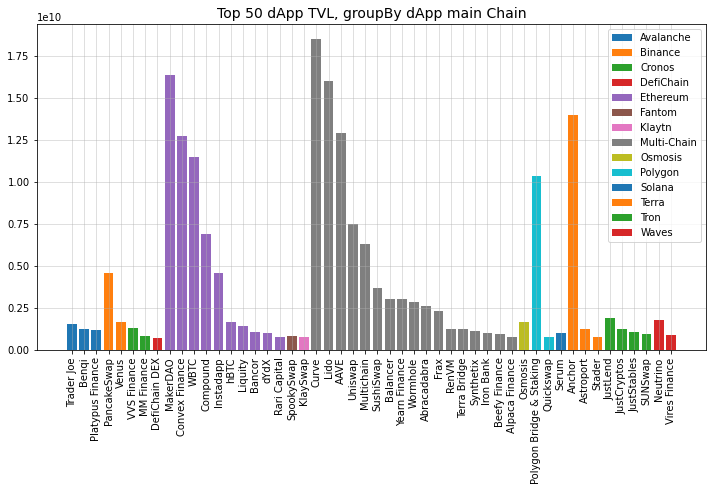

In [19]:
# Top 20 dapps TVL by Chain
import defi.defi_tools as dft
import matplotlib.pyplot as plt

df = dft.getProtocols()
fig, ax = plt.subplots(figsize=(12,6))

n = 50 # quantity to show
top = df.sort_values('tvl', ascending=False).head(n)

chains = top.groupby('chain').size().index.values.tolist()
for chain in chains:
    filtro = top.loc[top.chain==chain]
    ax.bar(filtro.index, filtro.tvl, label=chain)

ax.set_title(f'Top {n} dApp TVL, groupBy dApp main Chain', fontsize=14)
ax.grid(alpha=0.5)
plt.legend()
plt.xticks(rotation=90)
plt.show()

<AxesSubplot:xlabel='date'>

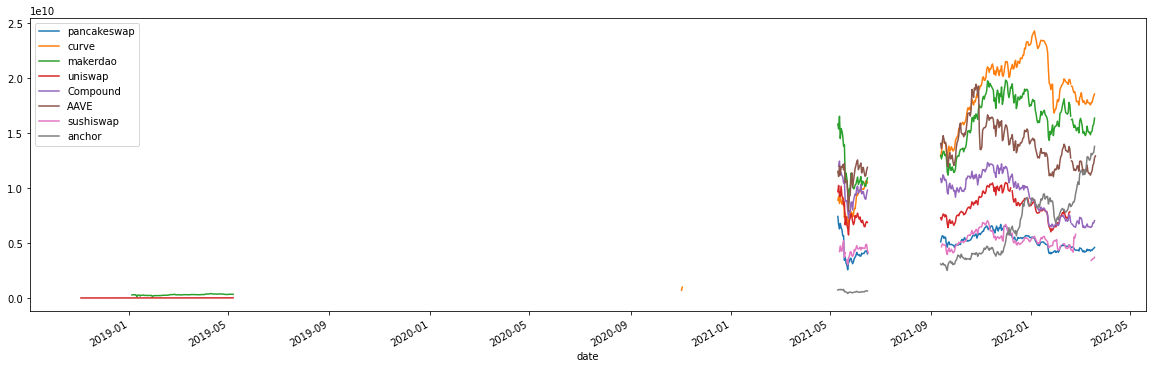

In [22]:
### Historical TVL
import defi.defi_tools as dft
import pandas as pd

exchanges = ['pancakeswap', 'curve', 'makerdao', 'uniswap','Compound', 'AAVE','sushiswap','anchor']

hist = [dft.getProtocol(exchange)[1] for exchange in exchanges]
df = pd.concat(hist, axis=1)
df.columns = exchanges

df.plot(figsize=(20,6))

{'Token 1': 'huobi-token',
 'Token 2': 'tether',
 'start': '2021-01-01',
 'fixed APR': '45%',
 'Buy & Hold': '54.39%',
 'Impermanent Loss': '-6.41%',
 'Farming Rewards': '109.48%',
 'Farming + Rewards - IL': '170.28%'}

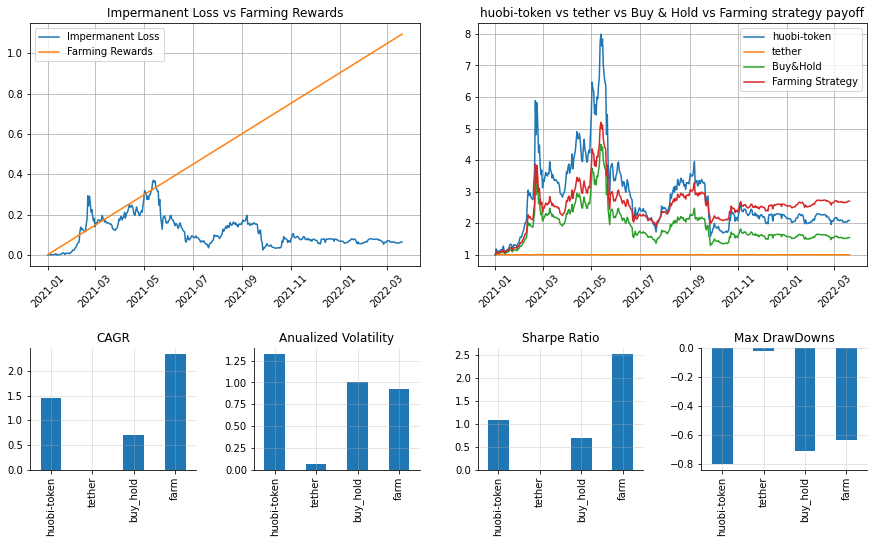

In [26]:
#CoinGecko API
#Endpoints available, some examples:

dft.getGeckoIDs()
    # coinGecko first 5000 ids

dft.geckoPrice("bitcoin,ethereum", "usd,eur,brl")
	# coinGecko quotes

dft.geckoList(page=1, per_page=250)
	# full coinGecko cyptocurrency list

dft.geckoMarkets("ethereum")
	# top 100 liquidity markets, prices, and more, for eth or other coin

dft.geckoHistorical('cardano')
	# full history containing price, market cap and volume 

dft.farmSimulate(['huobi-token','tether'], apr=45)
    # Simulate farming strategy with apr=45% 

In [28]:
# CoinGecko - ids list

ids = dft.getGeckoIDs()
ids[:10]

['bitcoin',
 'ethereum',
 'tether',
 'binancecoin',
 'usd-coin',
 'ripple',
 'terra-luna',
 'solana',
 'cardano',
 'avalanche-2']

In [29]:
#CoinGecko - Get price for coins at diferent currencies

dft.geckoPrice("bitcoin,ethereum", "usd,eur,brl")

{'bitcoin': {'usd': 41894, 'eur': 37861, 'brl': 210464},
 'ethereum': {'usd': 2923.91, 'eur': 2642.44, 'brl': 14689.01}}

In [30]:
#CoinGecko - Get main exchanges for a coin or token

df = dft.geckoMarkets("ethereum")
print(df.info())
# returns top 100 ethereum quotes by volume

<class 'pandas.core.frame.DataFrame'>
Index: 100 entries, Crypto.com Exchange to Coinlist
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype              
---  ------       --------------  -----              
 0   base         100 non-null    object             
 1   target       100 non-null    object             
 2   last         100 non-null    float64            
 3   volume       100 non-null    float64            
 4   spread       100 non-null    float64            
 5   timestamp    100 non-null    datetime64[ns, UTC]
 6   volume_usd   100 non-null    float64            
 7   price_usd    100 non-null    float64            
 8   trust_score  100 non-null    object             
dtypes: datetime64[ns, UTC](1), float64(5), object(3)
memory usage: 7.8+ KB
None


In [31]:
# CoinGecko - historical prices for a coin

df = dft.geckoHistorical('cardano')
print(df)

                        price   market_caps  total_volumes
date                                                      
2017-10-18 00:00:00  0.026845  6.960214e+08   2.351678e+06
2017-10-19 00:00:00  0.026830  6.956220e+08   2.815156e+06
2017-10-20 00:00:00  0.030300  7.855800e+08   8.883473e+06
2017-10-21 00:00:00  0.028588  7.412021e+08   5.308857e+06
2017-10-22 00:00:00  0.027796  7.206698e+08   2.901876e+06
...                       ...           ...            ...
2022-03-16 00:00:00  0.800408  2.571983e+10   6.725901e+08
2022-03-17 00:00:00  0.838234  2.654162e+10   9.697176e+08
2022-03-18 00:00:00  0.837683  2.683633e+10   7.315337e+08
2022-03-19 00:00:00  0.854059  2.740165e+10   6.332354e+08
2022-03-19 23:24:50  0.900045  2.877920e+10   8.619799e+08

[1615 rows x 3 columns]
